# Credit Card Fraud Detection - Modelling

Sections:
1. Time-based train/validation/test split
2. Baseline model (Logistic Regression)
3. XGBoost with three imbalance-handling strategies (compared side by side)
4. Fraud-specific evaluation (PR-AUC, card-precision@k, threshold analysis)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, confusion_matrix, classification_report
)
 
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import os

In [11]:
# Time-based train / validation / test split
# To account for:
# 1. Accurate reflection of real-world practice, where a fraud model is predicting based on historical data
# 2. Avoiding data leakage from aggregate engineered features (customer transactions & terminal risk scores over time windows)
# With a delay-period between train and test sets to reflect real-world time delay on detecting fraud

def get_train_val_test_set(transactions_df,
                            start_day_training,
                            delta_train=90,
                            delta_delay=7,
                            delta_val=20,
                            delta_test=26):
    """
    transactions_df : full dataframe, must contain TX_TIME_DAYS
    start_day_training : first day (int) of the training window
    delta_train : number of days in the training window
    delta_delay : gap (days) inserted before EACH of validation and test,
                  to simulate label-confirmation latency
    delta_val   : number of days in the validation window
    delta_test  : number of days in the test window
    """
    train_df = transactions_df[
        (transactions_df.TX_TIME_DAYS >= start_day_training) &
        (transactions_df.TX_TIME_DAYS < start_day_training + delta_train)
    ]
 
    val_start = start_day_training + delta_train + delta_delay
    val_df = transactions_df[
        (transactions_df.TX_TIME_DAYS >= val_start) &
        (transactions_df.TX_TIME_DAYS < val_start + delta_val)
    ]
 
    test_start = val_start + delta_val + delta_delay
    test_df = transactions_df[
        (transactions_df.TX_TIME_DAYS >= test_start) &
        (transactions_df.TX_TIME_DAYS < test_start + delta_test)
    ]
 
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))

In [12]:
# Feature set: discluding transformed datetime, customer id, and terminal id columns.

FEATURES = [
    'TX_AMOUNT', 'TX_DURING_WEEKEND', 'TX_DURING_NIGHT',
    'CUSTOMER_ID_NB_TX_1DAY_WINDOW', 'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW',
    'CUSTOMER_ID_NB_TX_7DAY_WINDOW', 'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW',
    'CUSTOMER_ID_NB_TX_30DAY_WINDOW', 'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW',
    'TERMINAL_ID_NB_TX_1DAY_WINDOW', 'TERMINAL_ID_RISK_1DAY_WINDOW',
    'TERMINAL_ID_NB_TX_7DAY_WINDOW', 'TERMINAL_ID_RISK_7DAY_WINDOW',
    'TERMINAL_ID_NB_TX_30DAY_WINDOW', 'TERMINAL_ID_RISK_30DAY_WINDOW',
]
TARGET = 'TX_FRAUD'

In [13]:
# Baseline model - Logistic regression
# Using a balanced class weight to reweight the loss inversely proportional to class frequency, to account for <1% fraud cases

def train_baseline_logreg(train_df, features=FEATURES, target=TARGET):
    X_train = train_df[features]
    y_train = train_df[target]

    # Scaling since logistic regression is distance/gradient-based
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    return model, scaler

In [14]:
# XGBoost, testing 3 imbalance-handling strategies for personal understanding
#
# 1. scale_pos_weight: reweights the loss function directly. No change to data distribution.
# 2. SMOTE: synthesises new fraud points by interpolating between existing fraud points. 
#           Risk of creating unrealistic synthetic frauds & overfitting where minority class is sparse
# 3. Random undersampling: discards non-fraud points to balance classes. Trade-off of losing valuable information from the majority class.

def train_xgb_scale_pos_weight(train_df, val_df, features=FEATURES, target=TARGET):
    X_train, y_train = train_df[features], train_df[target]
    X_val, y_val = val_df[features], val_df[target]
    # scale_pos_weight = (# negative) / (# positive) is the standard XGBoost
    # recommendation for imbalanced binary classification.
    ratio = (y_train == 0).sum() / (y_train == 1).sum()
 
    model = XGBClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=ratio,
        eval_metric='aucpr',        # optimize for PR-AUC, not accuracy/logloss
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    print(f"  scale_pos_weight: stopped at {model.best_iteration} trees")
    return model
 
 
def train_xgb_smote(train_df, val_df, features=FEATURES, target=TARGET):
    X_train, y_train = train_df[features], train_df[target]
    X_val, y_val = val_df[features], val_df[target]
 
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
 
    model = XGBClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        eval_metric='aucpr',
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_res, y_res, eval_set=[(X_val, y_val)], verbose=False)
    print(f"  SMOTE: stopped at {model.best_iteration} trees")
    return model
 
 
def train_xgb_undersample(train_df, val_df, features=FEATURES, target=TARGET):
    X_train, y_train = train_df[features], train_df[target]
    X_val, y_val = val_df[features], val_df[target]
 
    rus = RandomUnderSampler(random_state=42)
    X_res, y_res = rus.fit_resample(X_train, y_train)
 
    model = XGBClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        eval_metric='aucpr',
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_res, y_res, eval_set=[(X_val, y_val)], verbose=False)
    print(f"  Undersampling: stopped at {model.best_iteration} trees")
    return model

In [25]:
# Evaluation
#
# No accuracy, as reporting no fraud for all cases would score 99%
#
# 1. PR-AUC: precision-recall area under curve, not inflated by true negatives
#            As a secondary metric, ROC-AUC: area under the receiver operating characteristic curve is reported 
#            for comparability with referenced works
#
# 2. Card precision top-k day: For a single day: rank transactions by predicted fraud score, take the top_k, and 
#                              compute what fraction of those top_k are actually fraud. Mirrors real-world fixed capacity to review K 
#                              transactions per day. Tells you: if analysts can only check the top e.g. 100 riskiest transactions today, 
#                              what fraction would actually be fraud?
#
# 3. Card precision top-k: above averaged for all days in the test set
#
# 4. Threshold report: works to a chose operating threshold, shows the confusion matrix and the trade-off 
#                      (false positives = wasted investigation effort vs. false negatives = fraud that slips through) at a chosen cutoff

def evaluate_model(model, test_df, features=FEATURES, target=TARGET,
                    model_name="model", scaler=None):
    X_test = test_df[features]
    y_test = test_df[target]
 
    if scaler is not None:
        X_test = scaler.transform(X_test)
 
    y_scores = model.predict_proba(X_test)[:, 1]
 
    pr_auc = average_precision_score(y_test, y_scores)
 
    roc_auc = roc_auc_score(y_test, y_scores)
 
    print(f"\n=== {model_name} ===")
    print(f"PR-AUC (average precision): {pr_auc:.4f}")
    print(f"ROC-AUC:                    {roc_auc:.4f}")
 
    return {
        'model_name': model_name,
        'y_test': y_test.values,
        'y_scores': y_scores,
        'pr_auc': pr_auc,
        'roc_auc': roc_auc,
        'test_df': test_df
    }
 
 
def card_precision_top_k_day(df_day, y_scores_day, top_k=100):
    day = df_day.copy()
    day['score'] = y_scores_day
    day = day.sort_values('score', ascending=False)
    top = day.head(top_k)
    if len(top) == 0:
        return np.nan
    return top[TARGET].sum() / len(top)
 
 
def card_precision_top_k(test_df, y_scores, top_k=100):
    df = test_df.copy()
    df['score'] = y_scores
    daily_precisions = []
    for day, group in df.groupby('TX_TIME_DAYS'):
        p = card_precision_top_k_day(group, group['score'], top_k=top_k)
        if not np.isnan(p):
            daily_precisions.append(p)
    return np.mean(daily_precisions), daily_precisions
 
 
def plot_pr_curves(results_list):
    """Overlay precision-recall curves for all models on one plot."""
    plt.figure(figsize=(8, 6))
    for res in results_list:
        precision, recall, _ = precision_recall_curve(res['y_test'], res['y_scores'])
        plt.plot(recall, precision,
                  label=f"{res['model_name']} (PR-AUC={res['pr_auc']:.3f})")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves — Model Comparison')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('pr_curves_comparison.png', dpi=150)
    plt.show()

def threshold_report(y_test, y_scores, threshold=0.5):
    y_pred = (y_scores >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion matrix at threshold={threshold}:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))
    return cm

In [26]:
# Added threshold decision process. Standard 0.5 threshold wasn't optimal for such an imbalanced set, over-flagged fraud
# at 23% precision. This function sweeps through thresholds to visualise the trade-off, so a threshold can be chosen
# to maximise fraud detection while keeping the false positive rate manageable. The chosen threshold can then be used to 
# generate a confusion matrix and classification report.


def threshold_sweep(y_true, y_scores, thresholds=None):
    """
    Compute precision, recall, and F1 across a range of thresholds.
    Returns a DataFrame — one row per threshold — for plotting or picking
    an operating point from.
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
 
    rows = []
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
 
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = (2 * precision * recall / (precision + recall)
              if precision and recall and (precision + recall) > 0 else np.nan)
 
        rows.append({'threshold': t, 'precision': precision,
                      'recall': recall, 'f1': f1,
                      'n_flagged': int((y_pred == 1).sum())})
 
    return pd.DataFrame(rows)
 
 
def plot_threshold_sweep(sweep_df, chosen_threshold=None):
    """Plot precision, recall, and F1 as functions of threshold."""
    plt.figure(figsize=(8, 6))
    plt.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision')
    plt.plot(sweep_df['threshold'], sweep_df['recall'], label='Recall')
    plt.plot(sweep_df['threshold'], sweep_df['f1'], label='F1', linestyle='--')
    if chosen_threshold is not None:
        plt.axvline(chosen_threshold, color='gray', linestyle=':',
                    label=f'Chosen threshold = {chosen_threshold:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision / Recall / F1 vs. Threshold (validation set)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('threshold_sweep.png', dpi=150)
    plt.show()
 
 
def choose_threshold(sweep_df, strategy='max_f1', min_precision=None):
    """
    strategy='max_f1'        : pick the threshold that maximizes F1 —
                                a balanced default when there's no explicit
                                business constraint.
    strategy='min_precision' : pick the LOWEST threshold that still
                                satisfies precision >= min_precision — use
                                this when the fraud team has stated "we
                                won't act on anything below X% confidence,"
                                and want to catch as much fraud as possible
                                within that constraint (maximizes recall
                                subject to the precision floor).
    """
    valid = sweep_df.dropna(subset=['precision', 'recall', 'f1'])
 
    if strategy == 'max_f1':
        best_row = valid.loc[valid['f1'].idxmax()]
    elif strategy == 'min_precision':
        if min_precision is None:
            raise ValueError("min_precision must be set when strategy='min_precision'")
        candidates = valid[valid['precision'] >= min_precision]
        if len(candidates) == 0:
            raise ValueError(f"No threshold reaches precision >= {min_precision}. "
                              f"Max achievable precision is {valid['precision'].max():.3f}.")
        best_row = candidates.loc[candidates['threshold'].idxmin()]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
 
    print(f"\nChosen threshold = {best_row['threshold']:.3f} "
          f"(strategy='{strategy}')")
    print(f"  Precision: {best_row['precision']:.4f}")
    print(f"  Recall:    {best_row['recall']:.4f}")
    print(f"  F1:        {best_row['f1']:.4f}")
    print(f"  Transactions flagged/day (approx): {best_row['n_flagged']:.0f}")
 
    return best_row['threshold']

In [27]:
def read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE):
    
    files = [os.path.join(DIR_INPUT, f) for f in os.listdir(DIR_INPUT) if f>=BEGIN_DATE+'.pkl' and f<=END_DATE+'.pkl']

    frames = []
    for f in files:
        df = pd.read_pickle(f)
        frames.append(df)
        del df
    df_final = pd.concat(frames)
    
    df_final=df_final.sort_values('TRANSACTION_ID')
    df_final.reset_index(drop=True,inplace=True)
    #  Note: -1 are missing values for real world data 
    df_final=df_final.replace([-1],0)
    
    return df_final

Load  files
Train     : 862358 tx, 7558 fraud (0.876%)
Validation: 191520 tx, 1689 fraud (0.882%)
Test      : 249527 tx, 2197 fraud (0.880%)

=== Logistic Regression (baseline) ===
PR-AUC (average precision): 0.5803
ROC-AUC:                    0.8952

Training XGBoost variants (early stopping on validation PR-AUC)...
  scale_pos_weight: stopped at 509 trees

=== XGBoost (scale_pos_weight) ===
PR-AUC (average precision): 0.7200
ROC-AUC:                    0.8942
  SMOTE: stopped at 12 trees

=== XGBoost (SMOTE) ===
PR-AUC (average precision): 0.6808
ROC-AUC:                    0.8927
  Undersampling: stopped at 479 trees

=== XGBoost (undersampling) ===
PR-AUC (average precision): 0.7418
ROC-AUC:                    0.8967

Best model on validation (by PR-AUC): XGBoost (undersampling)
Validation Card-Precision@85: 0.7147

--------------------------------------------------
THRESHOLD SELECTION (validation set)
--------------------------------------------------

Chosen threshold = 0.810 (st

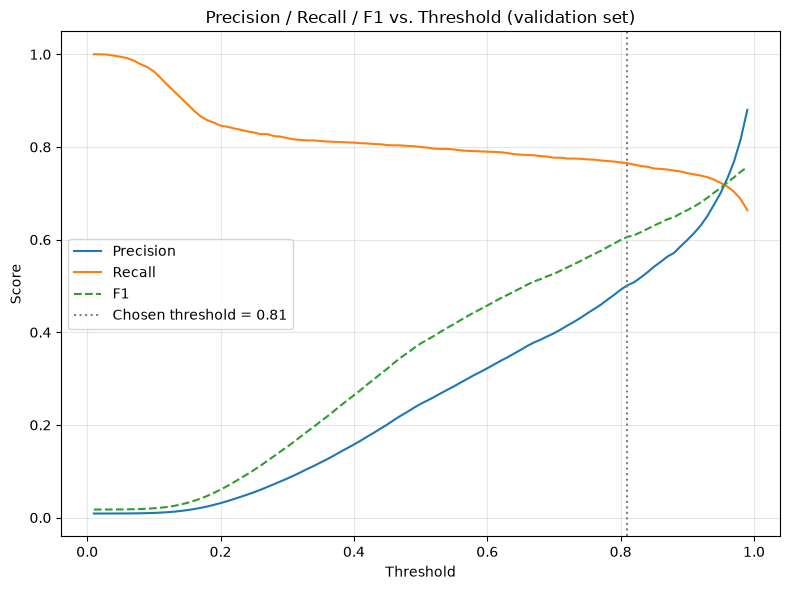


TEST SET EVALUATION

=== XGBoost (undersampling) [FINAL] ===
PR-AUC (average precision): 0.7368
ROC-AUC:                    0.9018
Test Card-Precision@85 (avg across test days): 0.7131


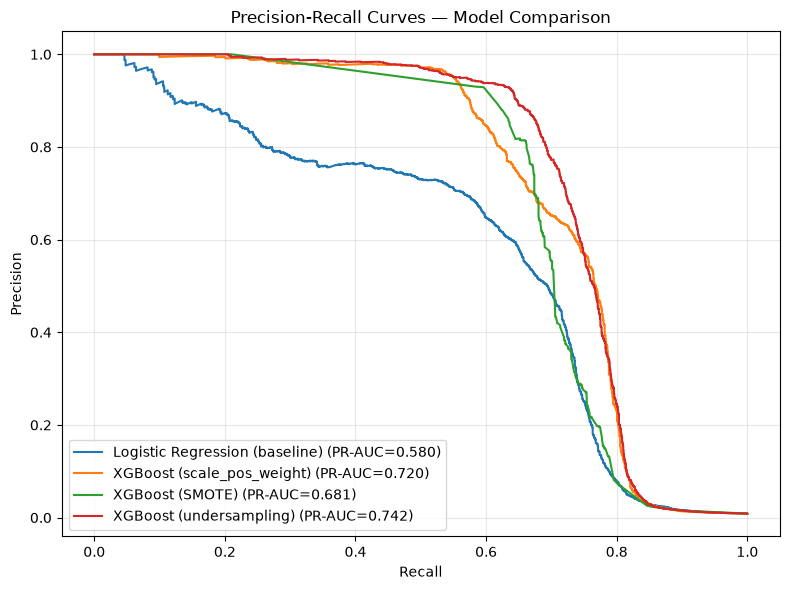


Applying validation-chosen threshold (0.810) to test set:

Confusion matrix at threshold=0.81:
[[245544   1786]
 [   516   1681]]

Classification report:
              precision    recall  f1-score   support

           0     0.9979    0.9928    0.9953    247330
           1     0.4849    0.7651    0.5936      2197

    accuracy                         0.9908    249527
   macro avg     0.7414    0.8790    0.7945    249527
weighted avg     0.9934    0.9908    0.9918    249527


For comparison, the naive default threshold=0.5:

Confusion matrix at threshold=0.5:
[[241518   5812]
 [   452   1745]]

Classification report:
              precision    recall  f1-score   support

           0     0.9981    0.9765    0.9872    247330
           1     0.2309    0.7943    0.3578      2197

    accuracy                         0.9749    249527
   macro avg     0.6145    0.8854    0.6725    249527
weighted avg     0.9914    0.9749    0.9817    249527



array([[241518,   5812],
       [   452,   1745]])

In [28]:
DIR_INPUT='../data/simulated-data-transformed' 

# Using the last 150 days to exclude the first month of data, which is fraud-sparse due to the 14-day and 28-day recurring 
# fraud scenarios needing at least one full cycle to start showing up.

BEGIN_DATE = "2025-12-02"
END_DATE = "2026-05-02"

print("Load  files")
transactions_df = read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)

total_days = transactions_df.TX_TIME_DAYS.max() + 1
start_day_training = int(total_days) - 150
assert start_day_training >= 0, "Fewer than 150 days available."

train_df, val_df, test_df = get_train_val_test_set(
    transactions_df,
    start_day_training=start_day_training,
    delta_train=90,
    delta_delay=7,
    delta_val=20,
    delta_test=26
)
for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f"{name:10s}: {len(df):6d} tx, {int(df[TARGET].sum()):4d} fraud "
            f"({100*df[TARGET].mean():.3f}%)")

val_results = []   # used only for model selection / threshold tuning
test_results = [] 

# --- Baseline ---
logreg_model, scaler = train_baseline_logreg(train_df)
val_results.append(evaluate_model(
    logreg_model, val_df, model_name="Logistic Regression (baseline)",
    scaler=scaler
))

# --- XGBoost variants (early stopping using val_df) ---
print("\nTraining XGBoost variants (early stopping on validation PR-AUC)...")
xgb_spw = train_xgb_scale_pos_weight(train_df, val_df)
val_results.append(evaluate_model(
    xgb_spw, val_df, model_name="XGBoost (scale_pos_weight)"
))

xgb_smote = train_xgb_smote(train_df, val_df)
val_results.append(evaluate_model(
    xgb_smote, val_df, model_name="XGBoost (SMOTE)"
))

xgb_under = train_xgb_undersample(train_df, val_df)
val_results.append(evaluate_model(
    xgb_under, val_df, model_name="XGBoost (undersampling)"
))

# --- Model selection ---
best_val = max(val_results, key=lambda r: r['pr_auc'])
print(f"\nBest model on validation (by PR-AUC): {best_val['model_name']}")

best_model_map = {
    "Logistic Regression (baseline)": (logreg_model, scaler),
    "XGBoost (scale_pos_weight)": (xgb_spw, None),
    "XGBoost (SMOTE)": (xgb_smote, None),
    "XGBoost (undersampling)": (xgb_under, None),
}
best_model, best_scaler = best_model_map[best_val['model_name']]

# --- Tune top_k and threshold on validation only ---
val_mean_prec_k, _ = card_precision_top_k(
    best_val['test_df'], best_val['y_scores'], top_k=85
    # top_k=85 chosen to match the average simulated daily fraud volume
    # "if analysts can review ~85 flagged transactions/day,
    # what fraction are real fraud?"
)
print(f"Validation Card-Precision@85: {val_mean_prec_k:.4f}")


# --- Threshold sweep, computed on VALIDATION only ---
print("\n" + "-" * 50)
print("THRESHOLD SELECTION (validation set)")
print("-" * 50)
sweep_df = threshold_sweep(best_val['y_test'], best_val['y_scores'])


threshold_precision = choose_threshold(
    sweep_df, strategy='min_precision', min_precision=0.5
    # nothing under 50% confidence is flagged, then recall is maximised
)

# alternative method - 
# threshold_f1 = choose_threshold(sweep_df, strategy='max_f1')

chosen_threshold = threshold_precision
plot_threshold_sweep(sweep_df, chosen_threshold=chosen_threshold)

# --- Final evaluation on the test set ---
print("\n" + "=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
final_result = evaluate_model(
    best_model, test_df, model_name=f"{best_val['model_name']} [FINAL]",
    scaler=best_scaler
)
test_mean_prec_k, daily_prec_k = card_precision_top_k(
    test_df, final_result['y_scores'], top_k=85
)
print(f"Test Card-Precision@85 (avg across test days): {test_mean_prec_k:.4f}")

plot_pr_curves(val_results)

print(f"\nApplying validation-chosen threshold ({chosen_threshold:.3f}) to test set:")
threshold_report(final_result['y_test'], final_result['y_scores'],
                    threshold=chosen_threshold)

print("\nFor comparison, the naive default threshold=0.5:")
threshold_report(final_result['y_test'], final_result['y_scores'], threshold=0.5)
 